# Разбор данных

In [71]:
from os import name

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


In [2]:
train = pd.read_parquet('data/train.parquet')

In [3]:
train.head()

,user_id,communication_type,treatment_flg,rec_spend,age,n_days_life,gendercalc,n_plastic_card,n_virtual_card,rto,...,cus_cat_5_last_2_3_days,cus_cat_5_max_min_days_diff,cus_cat_5_last_1_days,cus_cat_5_last_2_days,cus_cat_5_last_3_days,cus_mark_fav_cat_accept_flg_1_month_ago,cus_mark_fav_cat_accept_flg_2_month_ago,cus_mark_n_offers,cus_mark_n_view,cus_mark_n_rule
0,272706,com_type_1,1,0.00,31.0,1848.0,0.0,1.0,1.0,7010.0,...,14.0,303.0,15.0,69.0,83.0,1.0,1.0,32.0,14.0,2.0
1,314387,com_type_1,0,0.00,36.0,1713.0,1.0,1.0,1.0,17049.0,...,NaN,10.0,18.0,28.0,NaN,1.0,NaN,60.0,8.0,1.0
2,104701,com_type_3,1,0.00,15.0,136.0,0.0,NaN,1.0,20811.0,...,NaN,54.0,8.0,62.0,NaN,NaN,1.0,78.0,17.0,4.0
3,196313,com_type_2,0,0.00,25.0,1693.0,0.0,NaN,1.0,13307.0,...,10.0,168.0,90.0,151.0,161.0,1.0,NaN,44.0,3.0,3.0
4,261343,com_type_2,0,189.99,28.0,1879.0,0.0,1.0,1.0,21457.0,...,2.0,361.0,5.0,11.0,13.0,NaN,NaN,76.0,1.0,1.0


In [4]:
pd.unique(train.user_id).shape[0]

355246

ID клиентов не повторяется.

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 355246 entries, 0 to 355245
Data columns (total 89 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   user_id                                  355246 non-null  int64  
 1   communication_type                       355246 non-null  object 
 2   treatment_flg                            355246 non-null  int32  
 3   rec_spend                                355246 non-null  float64
 4   age                                      355237 non-null  float64
 5   n_days_life                              355005 non-null  float64
 6   gendercalc                               343923 non-null  float64
 7   n_plastic_card                           257949 non-null  float64
 8   n_virtual_card                           355239 non-null  float64
 9   rto                                      355233 non-null  float64
 10  atv                                      35

В датасете есть пропуски в данных

Text(0.5, 1.0, 'box plot for rec_spend')

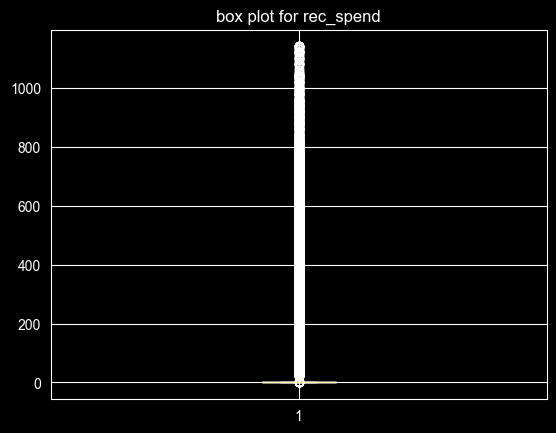

In [28]:
plt.boxplot(train['rec_spend'])
plt.title('box plot for rec_spend')

Text(0.5, 1.0, 'histogram for rec_spend')

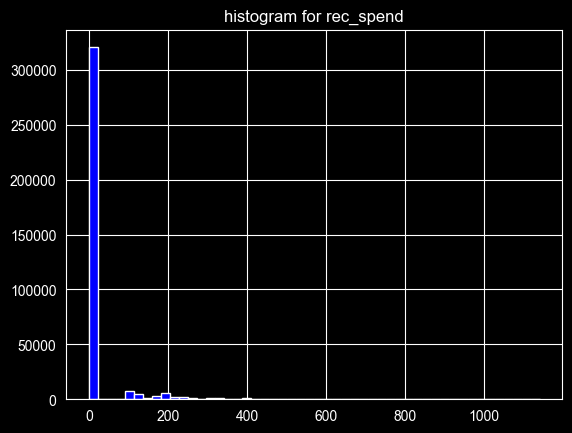

In [30]:
plt.hist(train['rec_spend'], bins=50, color='blue')
plt.title('histogram for rec_spend')

In [36]:
train.rec_spend.where(train.rec_spend ==0).count()/train.shape[0]

np.float64(0.9020340834238809)

Более 90% клиентов не совершали покупок во время периода акции.

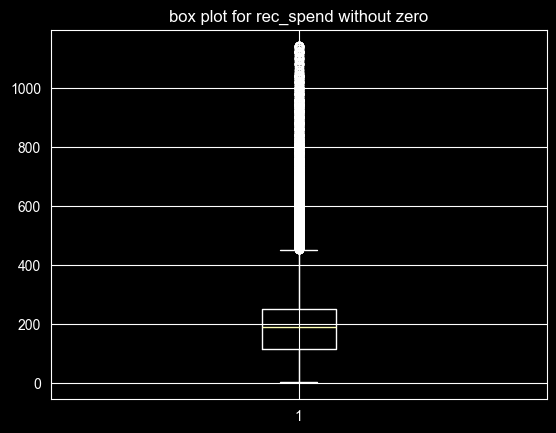

In [43]:
plt.boxplot(train[train['rec_spend']!=0]['rec_spend'])
plt.title('box plot for rec_spend without zero')
plt.show()

Медианное значение rec_spend для клиентов, которые совершали покупки, составляет 200 руб. При этом, 95% лежат в диапазоне от 0 до 450 руб.

In [59]:
train.treatment_flg.value_counts()

treatment_flg
0    179214
1    176032
Name: count, dtype: int64

Классы в датасете сбалансированы, по количеству.

In [62]:
def compute_smd(df, treatment_col='treatment_flg'):
    """
    Вычисляет SMD для всех числовых признаков относительно treatment_flg.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if treatment_col in numeric_cols:
        numeric_cols.remove(treatment_col)
    if 'user_id' in numeric_cols:
        numeric_cols.remove('user_id')

    results = []
    for col in numeric_cols:
        mean_t = df[df[treatment_col]==1][col].mean()
        mean_c = df[df[treatment_col]==0][col].mean()
        var_t = df[df[treatment_col]==1][col].var(ddof=1)
        var_c = df[df[treatment_col]==0][col].var(ddof=1)
        pooled_std = np.sqrt((var_t + var_c) / 2)
        if pooled_std == 0:
            smd = 0
        else:
            smd = (mean_t - mean_c) / pooled_std
        results.append({'feature': col, 'smd': smd})

    return pd.DataFrame(results).sort_values('smd', key=abs, ascending=False)

                                    feature       smd
0                                 rec_spend  0.040688
19                             rto_format_2 -0.020260
25                                  n_cat_5 -0.014319
54                  cus_cat_7_last_2_3_days  0.014147
40                            cus_cat_6_std -0.013102
..                                      ...       ...
34                            cus_cat_7_atv -0.000249
2                               n_days_life  0.000046
44                            cus_cat_5_atv -0.000022
81  cus_mark_fav_cat_accept_flg_1_month_ago  0.000000
82  cus_mark_fav_cat_accept_flg_2_month_ago  0.000000

[86 rows x 2 columns]


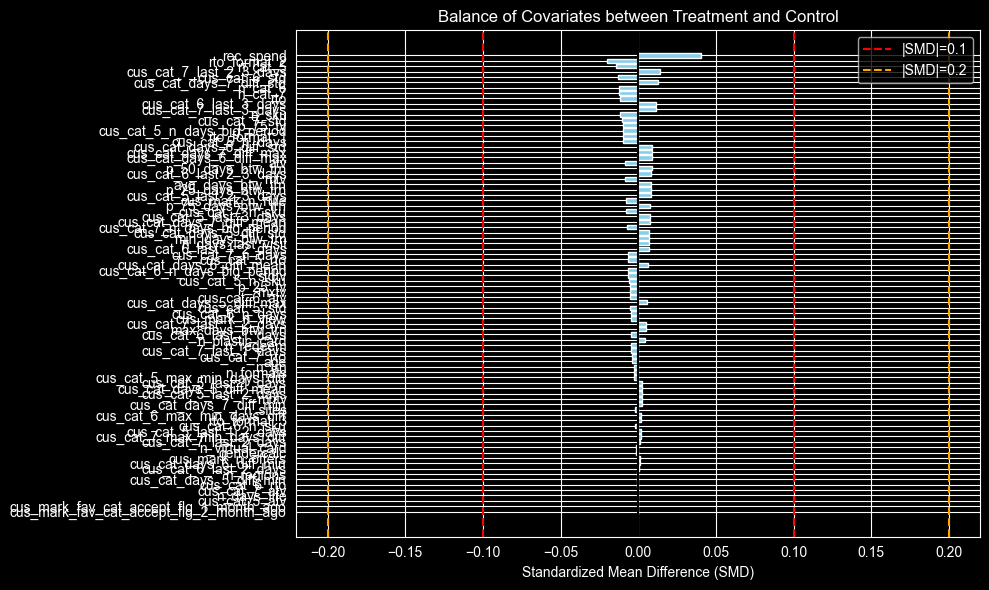

In [61]:
smd_df = compute_smd(train, treatment_col='treatment_flg')
print(smd_df)

plt.figure(figsize=(10, 6))
smd_plot = smd_df.copy()
smd_plot['abs_smd'] = smd_plot['smd'].abs()
smd_plot = smd_plot.sort_values('abs_smd')
plt.barh(smd_plot['feature'], smd_plot['smd'], color='skyblue')
plt.axvline(x=0, color='black', linestyle='-')
plt.axvline(x=0.1, color='red', linestyle='--', label='|SMD|=0.1')
plt.axvline(x=-0.1, color='red', linestyle='--')
plt.axvline(x=0.2, color='orange', linestyle='--', label='|SMD|=0.2')
plt.axvline(x=-0.2, color='orange', linestyle='--')
plt.xlabel('Standardized Mean Difference (SMD)')
plt.title('Balance of Covariates between Treatment and Control')
plt.legend()
plt.tight_layout()
plt.show()

Значения SMD для всех признаков находятся в интервале примерно от -0.05 до +0.05. Treatment и control группы практически идентичны по распределениям всех ковариат.


=== Cross-tab for communication_type ===
Treatment proportion by category:
treatment_flg              0         1
communication_type                    
com_type_1          0.504780  0.495220
com_type_2          0.503376  0.496624
com_type_3          0.505280  0.494720

Mean rec_spend by category and treatment:
treatment_flg               0          1
communication_type                      
com_type_1          19.395029  23.173169
com_type_2          19.887403  21.310010
com_type_3          19.398774  23.771161


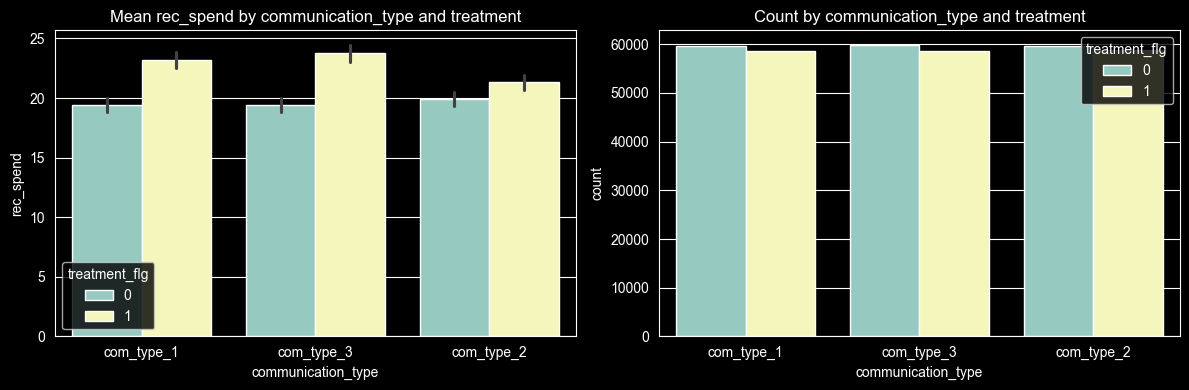


=== Cross-tab for gendercalc ===
Treatment proportion by category:
treatment_flg         0         1
gendercalc                       
0.0            0.504218  0.495782
1.0            0.504901  0.495099

Mean rec_spend by category and treatment:
treatment_flg          0          1
gendercalc                         
0.0            20.048999  23.423251
1.0            18.342880  21.108734


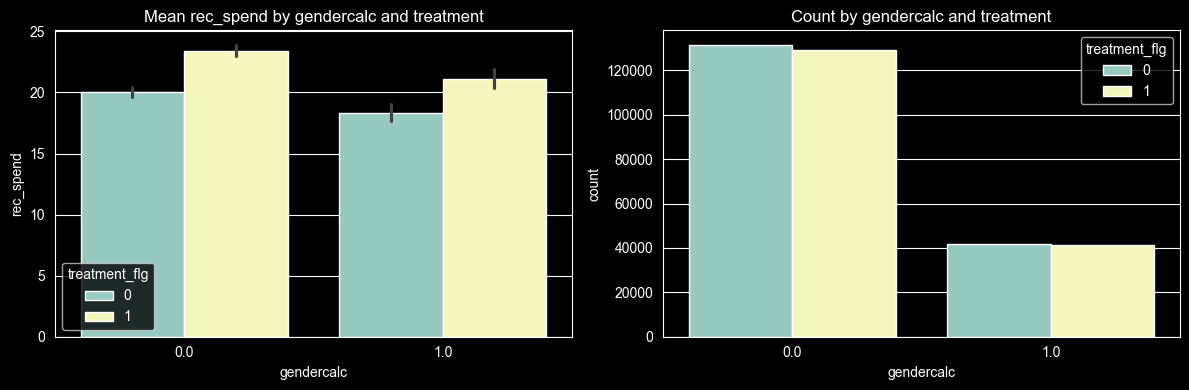

In [66]:
cat_cols = ['communication_type', 'gendercalc']

for col in cat_cols:
    print(f"\n=== Cross-tab for {col} ===")
    ct = pd.crosstab(train[col], train['treatment_flg'], normalize='index')
    print("Treatment proportion by category:")
    print(ct)
    mean_spend = train.groupby([col, 'treatment_flg'])['rec_spend'].mean().unstack()
    print("\nMean rec_spend by category and treatment:")
    print(mean_spend)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=train, x=col, y='rec_spend', hue='treatment_flg', ax=axes[0])
    axes[0].set_title(f'Mean rec_spend by {col} and treatment')
    sns.countplot(data=train, x=col, hue='treatment_flg', ax=axes[1])
    axes[1].set_title(f'Count by {col} and treatment')
    plt.tight_layout()
    plt.show()

Балансировка treatment/control идеальна во всех категориях communication_type и gendercalc
Uplift присутствует во всех сегментах:
- По communication_type: прирост rec_spend от +1.4 (com_type_2) до +4.4 (com_type_3). Лучший канал – com_type_3.
- По gendercalc: прирост ≈ +3.4 для 0.0 и ≈ +2.8 для 1.0. Клиенты с gendercalc=0.0 в среднем тратят больше в контроле и дают больший абсолютный uplift.

Модель должна использовать communication_type как важный признак (или строить отдельные модели по каналам), а gendercalc – как сильный предиктор гетерогенности. com_type_2 даёт наименьший uplift – возможно, этот канал требует отдельной настройки или исключения из таргетинга.

Descriptive statistics for numeric features:
                 age    n_days_life     gendercalc  n_plastic_card  \
count  355237.000000  355005.000000  343923.000000   257949.000000   
mean       38.769951    1371.386566       0.241778        1.274329   
std        13.279615     549.515103       0.428161        0.544401   
min         5.000000      42.000000       0.000000        1.000000   
1%         16.000000     110.000000       0.000000        1.000000   
5%         19.000000     247.000000       0.000000        1.000000   
25%        30.000000     973.000000       0.000000        1.000000   
50%        37.000000    1664.000000       0.000000        1.000000   
75%        47.000000    1793.000000       0.000000        1.000000   
95%        62.000000    1911.000000       1.000000        2.000000   
99%        71.000000    2004.000000       1.000000        3.000000   
max       156.000000    2152.000000       1.000000       11.000000   

       n_virtual_card            rto        

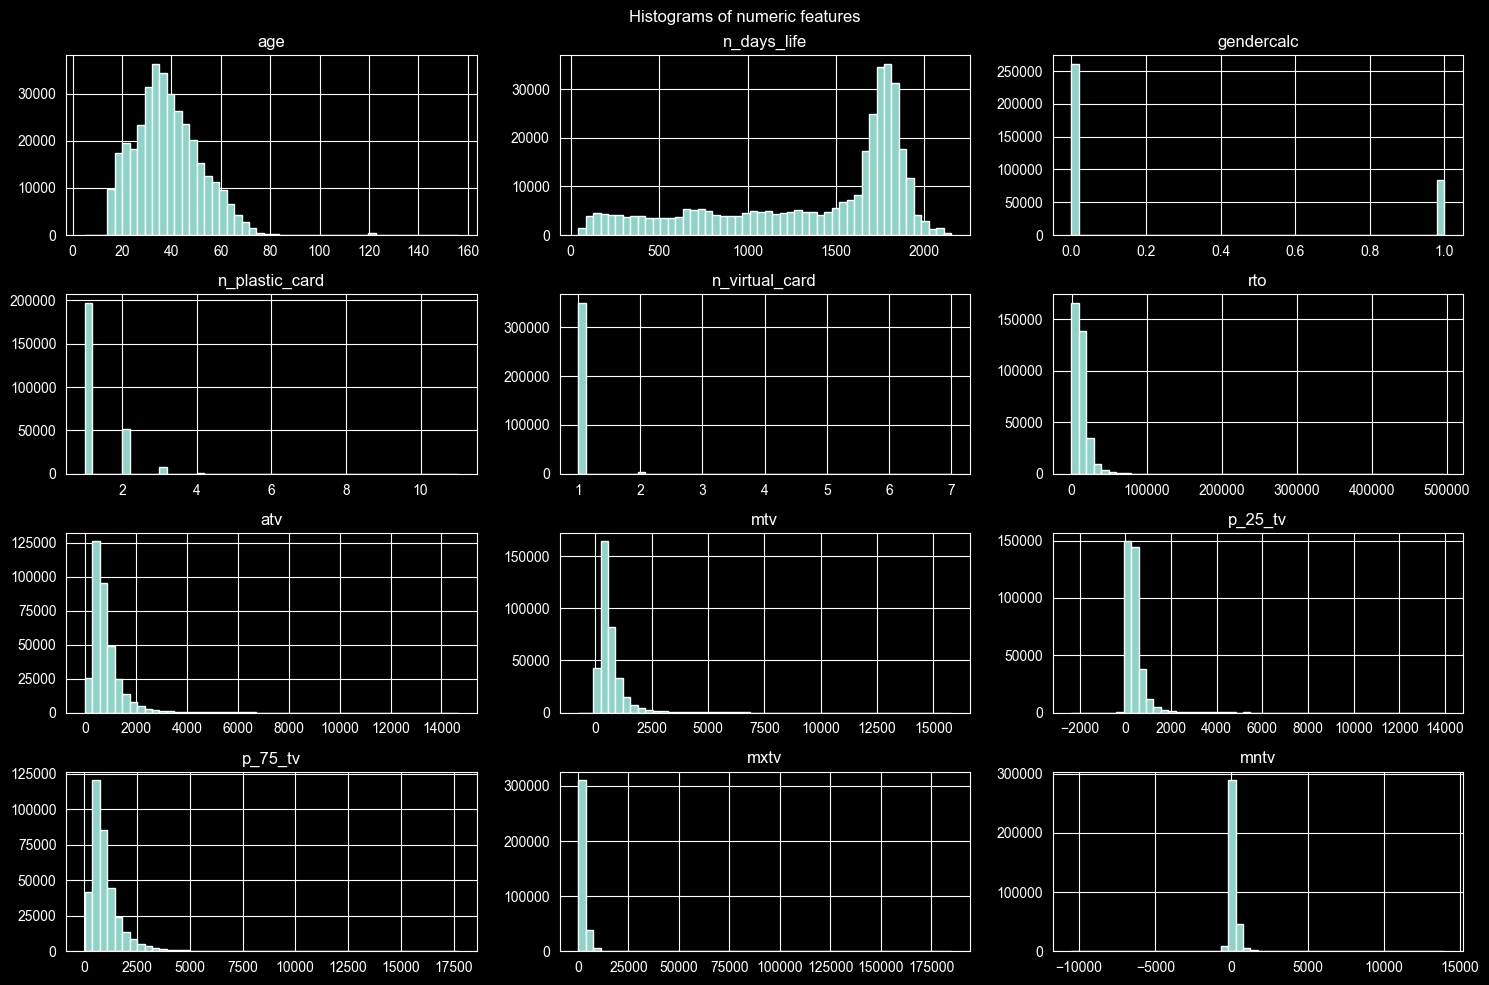

In [67]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['user_id', 'treatment_flg', 'rec_spend']
numeric_cols = [c for c in numeric_cols if c not in exclude]

desc = train[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("Descriptive statistics for numeric features:")
print(desc)

for col in numeric_cols:
    inf_count = np.isinf(train[col]).sum()
    if inf_count > 0:
        print(f"{col}: {inf_count} infinite values")
    if 'age' in col:
        strange = train[(train[col] < 0) | (train[col] > 120)].shape[0]
        if strange > 0:
            print(f"{col}: {strange} values outside [0,120]")

train[numeric_cols[:12]].hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms of numeric features')
plt.tight_layout()
plt.show()

Данные требуют очистки: отрицательные значения в тратах (rto, atv, mtv и др.) заменить на 0; возраст >120 ограничить 120; пропуски в n_plastic_card, gendercalc, cus_cat_* заполнить 0 (для сумм/SKU) или большим числом (для дней), а признаки cus_mark_fav_cat_accept_flg_* (все 1) удалить как бесполезные.


Correlation with rec_spend (all data):
rec_spend                                  1.000000
cus_cat_7_rto                              0.275040
cus_cat_6_rto                              0.264604
cus_cat_7_n_days                           0.255044
cus_cat_7_n_days_big_period                0.254217
                                             ...   
cus_cat_7_last_2_days                     -0.178876
cus_cat_6_last_3_days                     -0.186349
cus_cat_7_last_3_days                     -0.190025
cus_mark_fav_cat_accept_flg_1_month_ago         NaN
cus_mark_fav_cat_accept_flg_2_month_ago         NaN
Name: rec_spend, Length: 86, dtype: float64

Correlation with rec_spend (non-zero only):
rec_spend                                  1.000000
cus_cat_7_atv                              0.361993
cus_cat_6_atv                              0.353470
cus_cat_7_rto                              0.295864
cus_cat_6_rto                              0.289561
                                       

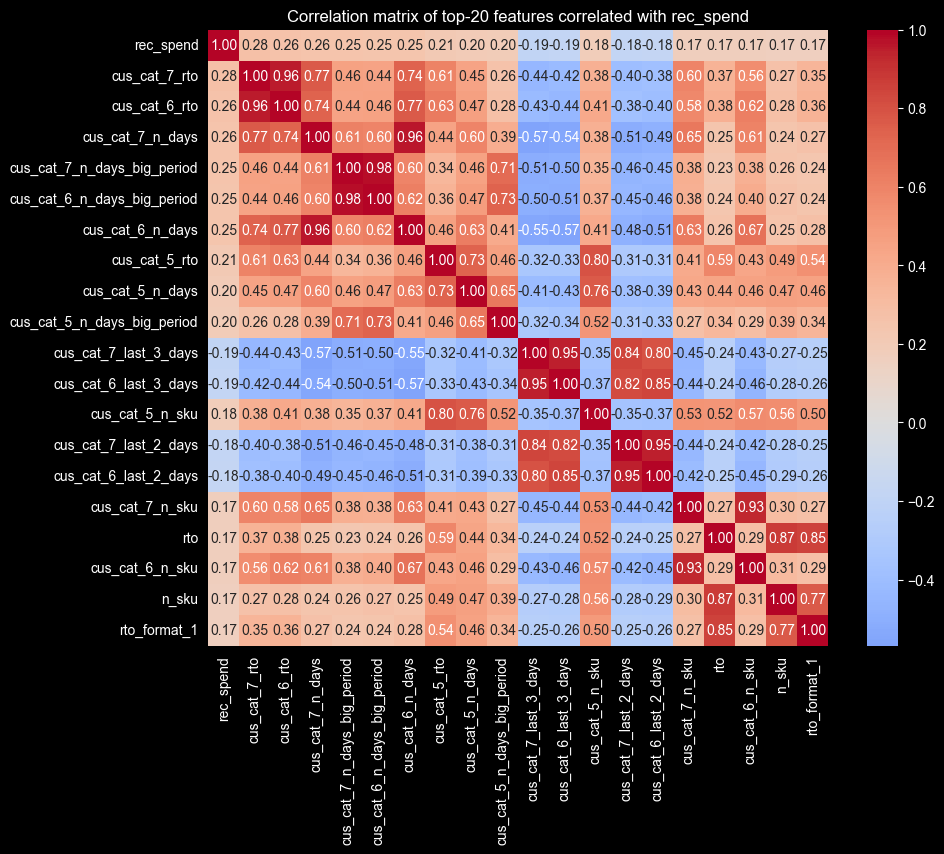

In [68]:
corr_all = train[numeric_cols + ['rec_spend']].corr()['rec_spend'].sort_values(ascending=False)
print("\nCorrelation with rec_spend (all data):")
print(corr_all)

nonzero = train[train['rec_spend'] > 0]
if len(nonzero) > 0:
    corr_nonzero = nonzero[numeric_cols + ['rec_spend']].corr()['rec_spend'].sort_values(ascending=False)
    print("\nCorrelation with rec_spend (non-zero only):")
    print(corr_nonzero)

top_corr = corr_all.abs().nlargest(20).index
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix of top-20 features correlated with rec_spend')
plt.show()

- Сильные положительные корреляции с cus_cat_7_rto, cus_cat_6_rto, cus_cat_7_n_days — траты и частота покупок в целевых категориях важнее всего.

- Отрицательные корреляции с cus_cat_*_last_*_days — чем давнее последняя покупка, тем ниже rec_spend.

- Признаки cus_mark_fav_cat_accept_flg_* — NaN (константа), их удалить.

- Для ненулевых rec_spend корреляции слабее, но структура та же.

In [72]:

X = train[numeric_cols].dropna()
X = add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print("\nVIF for numeric features (VIF > 10 indicates high multicollinearity):")
print(vif_data)


corr_matrix = train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[col, row]) for col in upper.columns for row in upper.index if upper.loc[col, row] > 0.9]
print(f"\nPairs with correlation > 0.9: {high_corr_pairs}")


D:\MAGNIT-HSE-Uplift-modeling\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
D:\MAGNIT-HSE-Uplift-modeling\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



VIF for numeric features (VIF > 10 indicates high multicollinearity):
                                    feature       VIF
79                    cus_cat_5_last_3_days       inf
77                    cus_cat_5_last_1_days       inf
75                  cus_cat_5_last_2_3_days       inf
63                  cus_cat_6_last_1_2_days       inf
52                  cus_cat_7_last_1_2_days       inf
..                                      ...       ...
3                            n_plastic_card  1.099721
2                                gendercalc  1.080160
4                            n_virtual_card  1.034164
80  cus_mark_fav_cat_accept_flg_1_month_ago  0.000000
81  cus_mark_fav_cat_accept_flg_2_month_ago  0.000000

[85 rows x 2 columns]

Pairs with correlation > 0.9: [('atv', 'mtv', np.float64(0.9214790623489225)), ('atv', 'p_75_tv', np.float64(0.9569226612431678)), ('mxtv', 'stdtv', np.float64(0.9292421978221319)), ('n_sku', 'n_cat_7', np.float64(0.9641580369280442)), ('n_sku', 'n_cat_6', 

- Мультиколлинеарность очень высокая: множество признаков имеют корреляцию >0.9 (например, atv с mtv и p_75_tv, n_sku с n_cat_7, признаки для cat_5/6/7 между собой).

- VIF для некоторых признаков = inf (идеальная линейная зависимость после удаления пропусков).

- Для деревенских моделей (LightGBM/CatBoost) это не проблема – они устойчивы к мультиколлинеарности.

- Для линейных meta-learners (S-learner, T-learner на линейной регрессии) нужно удалить коррелирующие признаки или применить регуляризацию (Ridge/Lasso).

- Рекомендация: оставить по одному из каждой группы сильно коррелирующих (например, cus_cat_7_rto вместо cus_cat_6_rto, atv вместо mtv и p_75_tv).

